In [ ]:
pip install umap-learn

Contagem regressiva finalizada. Executando o código...
Libraries imported and data loaded successfully, ready for UMAP processing.
UMAP calibrations defined successfully:
{'n_neighbors': 15, 'min_dist': 0.1, 'random_state': 42}
{'n_neighbors': 5, 'min_dist': 0.3, 'random_state': 42}
{'n_neighbors': 50, 'min_dist': 0.01, 'random_state': 42}


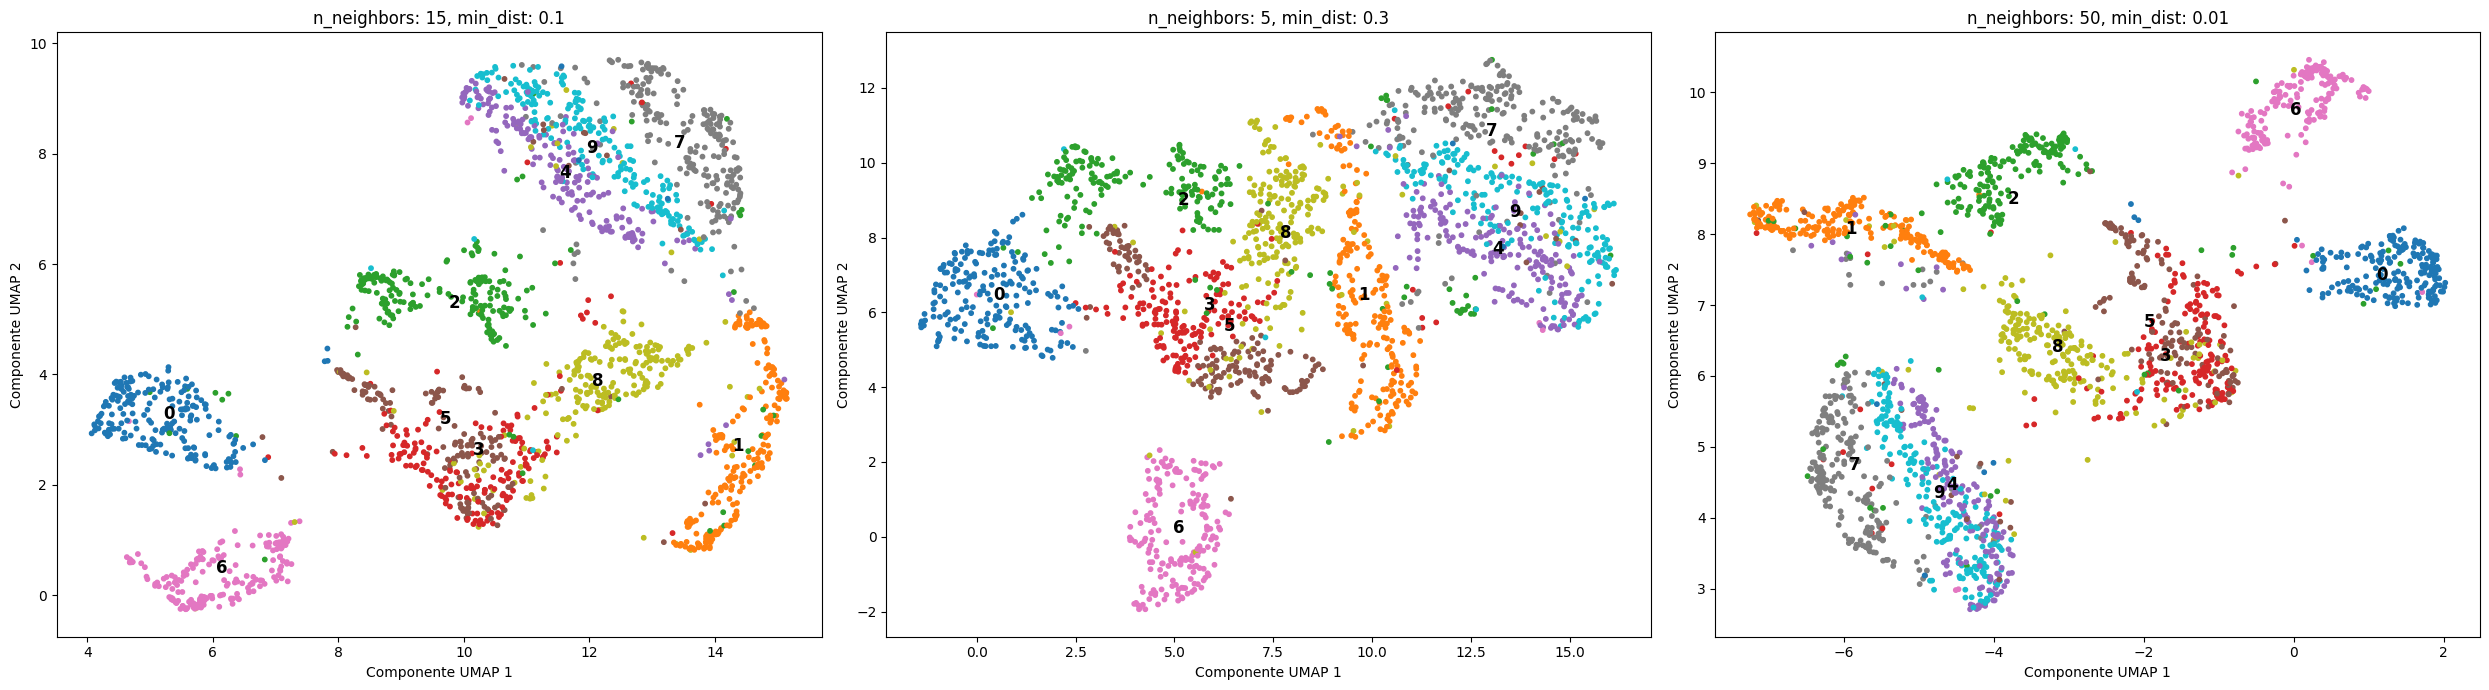

Searching for optimal UMAP parameters...
Testing n_neighbors=5, min_dist=0.0
Testing n_neighbors=5, min_dist=0.1
Testing n_neighbors=5, min_dist=0.3
Testing n_neighbors=5, min_dist=0.5
Testing n_neighbors=15, min_dist=0.0
Testing n_neighbors=15, min_dist=0.1
Testing n_neighbors=15, min_dist=0.3
Testing n_neighbors=15, min_dist=0.5
Testing n_neighbors=30, min_dist=0.0
Testing n_neighbors=30, min_dist=0.1
Testing n_neighbors=30, min_dist=0.3
Testing n_neighbors=30, min_dist=0.5
Testing n_neighbors=50, min_dist=0.0
Testing n_neighbors=50, min_dist=0.1
Testing n_neighbors=50, min_dist=0.3
Testing n_neighbors=50, min_dist=0.5

Melhor calibração UMAP: {'n_neighbors': 5, 'min_dist': 0.0}


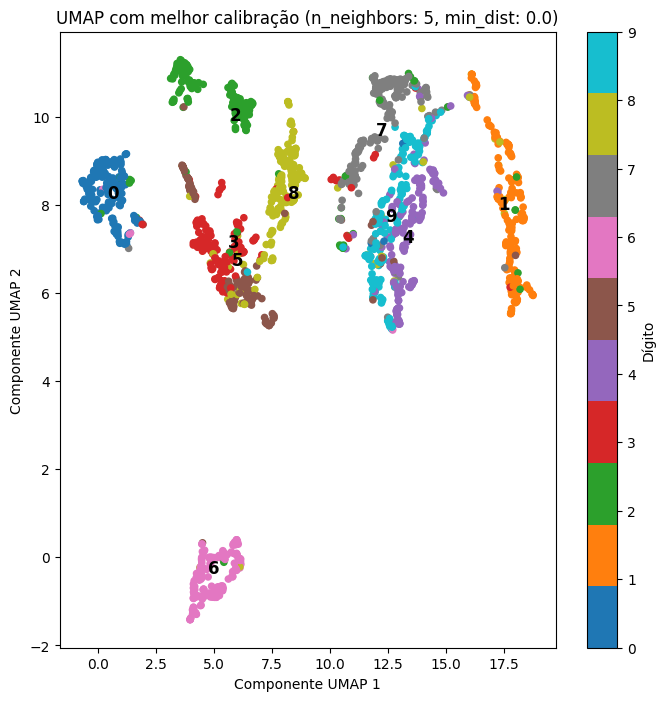

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from umap import UMAP # Replaced TSNE with UMAP
from sklearn.datasets import fetch_openml
from sklearn.metrics import silhouette_score
import time
from IPython.display import display, clear_output


# Contador regressivo de 9 minutos (kept as is)
print("Iniciando contagem regressiva de 9 minutos antes da execução do código...")
for i in range(546, 0, -1):
    mins, secs = divmod(i, 60)
    time_str = f"Tempo restante: {mins:02d}:{secs:02d}"
    clear_output(wait=True)
    print(time_str)
    time.sleep(1)
clear_output(wait=True)
print("Contagem regressiva finalizada. Executando o código...")

# Carregar dataset MNIST (kept as is)
mnist = fetch_openml('mnist_784')

# Selecionar um subconjunto de dados (para evitar problemas de memória) (kept as is)
np.random.seed(0)
idx = np.random.choice(mnist.data.shape[0], 2000, replace=False)
X = mnist.data.iloc[idx].astype('float64')
y = mnist.target.iloc[idx]

print("Libraries imported and data loaded successfully, ready for UMAP processing.")

calibracoes_umap = [
    {'n_neighbors': 15, 'min_dist': 0.1, 'random_state': 42}, # Common default values
    {'n_neighbors': 5, 'min_dist': 0.3, 'random_state': 42},  # Emphasizing local structure, more separation
    {'n_neighbors': 50, 'min_dist': 0.01, 'random_state': 42} # Emphasizing global structure, less separation
]

print("UMAP calibrations defined successfully:")
for cal in calibracoes_umap:
    print(cal)
fig, axs = plt.subplots(1, len(calibracoes_umap), figsize=(25, 7)) # Adjust figsize for better visualization

for i, calibracao in enumerate(calibracoes_umap):
    # Create UMAP reducer with n_components=2 for 2D visualization
    reducer = UMAP(n_components=2, **calibracao, n_jobs=1)

    # Fit and transform the data
    X_umap = reducer.fit_transform(X)

    # Plot the results
    axs[i].scatter(X_umap[:, 0], X_umap[:, 1], c=y.astype('int'), cmap='tab10', s=10)

    # Add digit labels to the plot
    for digit in np.unique(y.astype('int')):
        mask = (y.astype('int') == digit)
        X_umap_digit = X_umap[mask]

        center_x = X_umap_digit[:, 0].mean()
        center_y = X_umap_digit[:, 1].mean()

        axs[i].text(center_x, center_y, str(digit), ha='center', va='center', color='black', fontsize=12, fontweight='bold')

    axs[i].set_title(f"n_neighbors: {calibracao['n_neighbors']}, min_dist: {calibracao['min_dist']}")
    axs[i].set_xlabel('Componente UMAP 1')
    axs[i].set_ylabel('Componente UMAP 2')

plt.tight_layout()
plt.show()

import time

def calibracao_final_umap(X, y):
    melhor_calibracao = None
    melhor_score = -np.inf
    # Define a range of parameters to search
    n_neighbors_options = [5, 15, 30, 50]
    min_dist_options = [0.0, 0.1, 0.3, 0.5]

    print("Searching for optimal UMAP parameters...")
    for n_neighbors in n_neighbors_options:
        for min_dist in min_dist_options:
            print(f"Testing n_neighbors={n_neighbors}, min_dist={min_dist}")
            # Create UMAP reducer with n_components=2
            # Setting random_state for reproducibility
            reducer = UMAP(n_components=2, n_neighbors=n_neighbors, min_dist=min_dist, random_state=42, n_jobs=1)
            X_umap = reducer.fit_transform(X)

            # Use Silhouette Score to evaluate cluster separation
            # Ensure y is integer type for silhouette_score
            score = silhouette_score(X_umap, y.astype('int'))

            if score > melhor_score:
                melhor_score = score
                melhor_calibracao = {'n_neighbors': n_neighbors, 'min_dist': min_dist}
                melhor_X_umap = X_umap
    return melhor_calibracao, melhor_X_umap

start_time = time.time() # Start timer

melhor_calibracao_umap, melhor_X_umap = calibracao_final_umap(X, y)
print(f"\nMelhor calibração UMAP: {melhor_calibracao_umap}")

# Plot da UMAP na calibração final com rótulos de dígitos
plt.figure(figsize=(8, 8))
plt.scatter(melhor_X_umap[:, 0], melhor_X_umap[:, 1], c=y.astype('int'), cmap='tab10', s=20)

# Adicionar rótulos para cada dígito no plot final
for digit in np.unique(y.astype('int')):
    mask = (y.astype('int') == digit)
    X_umap_digit = melhor_X_umap[mask]
    center_x = X_umap_digit[:, 0].mean()
    center_y = X_umap_digit[:, 1].mean()
    plt.text(center_x, center_y, str(digit), ha='center', va='center', color='black', fontsize=12, fontweight='bold')

plt.title(f"UMAP com melhor calibração (n_neighbors: {melhor_calibracao_umap['n_neighbors']}, min_dist: {melhor_calibracao_umap['min_dist']})")
plt.xlabel('Componente UMAP 1')
plt.ylabel('Componente UMAP 2')
plt.colorbar(label='Dígito')
plt.show()